# Analistes del Perfil del Client: Quines combinacions de característiques demogràfiques (com edat, nivell educatiu i ocupació) són més comunes entre els clients que utilitzen múltiples productes financers del banc: lloen, hipoteca, dipòsit?

## cargar librerias y BBDD

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

data_path = r"C:\\LLUIS\Dropbox\\IT ACADEMY\\ProjecteData\\Equip_21\\Data\\Silver_BANK_marketing_020226.csv"

# Cargar el dataset con separador y encoding correctos
df = pd.read_csv(
    data_path,
    sep=",",
    encoding="utf-8"
)
df.head()


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59,admin.,married,secondary,0,2343.0,1,0,undefined_contact_type,5,may,1042,1,-1,0,new_marketing_client,1
1,2,56,admin.,married,secondary,0,45.0,0,0,undefined_contact_type,5,may,1467,1,-1,0,new_marketing_client,1
2,3,41,technician,married,secondary,0,1270.0,1,0,undefined_contact_type,5,may,1389,1,-1,0,new_marketing_client,1
3,4,55,services,married,secondary,0,2476.0,1,0,undefined_contact_type,5,may,579,1,-1,0,new_marketing_client,1
4,5,54,admin.,married,tertiary,0,184.0,0,0,undefined_contact_type,5,may,673,2,-1,0,new_marketing_client,1


# Preparar los datos
### Filtro inicial . Crear una variable(campo) para el conteo de productos

In [3]:
df["num_products"] = (
    df["loan"] +
    df["housing"] +
    df["deposit"]
)
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,num_products
0,1,59,admin.,married,secondary,0,2343.0,1,0,undefined_contact_type,5,may,1042,1,-1,0,new_marketing_client,1,2
1,2,56,admin.,married,secondary,0,45.0,0,0,undefined_contact_type,5,may,1467,1,-1,0,new_marketing_client,1,1
2,3,41,technician,married,secondary,0,1270.0,1,0,undefined_contact_type,5,may,1389,1,-1,0,new_marketing_client,1,2
3,4,55,services,married,secondary,0,2476.0,1,0,undefined_contact_type,5,may,579,1,-1,0,new_marketing_client,1,2
4,5,54,admin.,married,tertiary,0,184.0,0,0,undefined_contact_type,5,may,673,2,-1,0,new_marketing_client,1,1


__Este será el segmento multiproducto, que incluye:__

- Doble producto
- Triple producto

In [4]:
df["num_products"].value_counts().sort_index()


num_products
0    2119
1    6309
2    2457
3     265
Name: count, dtype: int64

### Creamos un campo categorico derivado del anterior para futuras visualizaciones y analisis

In [5]:
df["product_segment"] = df["num_products"].map({
    0: "0 productos",
    1: "1 producto",
    2: "2 productos",
    3: "3 productos"
})
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,num_products,product_segment
0,1,59,admin.,married,secondary,0,2343.0,1,0,undefined_contact_type,5,may,1042,1,-1,0,new_marketing_client,1,2,2 productos
1,2,56,admin.,married,secondary,0,45.0,0,0,undefined_contact_type,5,may,1467,1,-1,0,new_marketing_client,1,1,1 producto
2,3,41,technician,married,secondary,0,1270.0,1,0,undefined_contact_type,5,may,1389,1,-1,0,new_marketing_client,1,2,2 productos
3,4,55,services,married,secondary,0,2476.0,1,0,undefined_contact_type,5,may,579,1,-1,0,new_marketing_client,1,2,2 productos
4,5,54,admin.,married,tertiary,0,184.0,0,0,undefined_contact_type,5,may,673,2,-1,0,new_marketing_client,1,1,1 producto


### Crear rangos de edad antes del groupby, para que los resultados sean interpretables

In [6]:
bins = [17, 25, 30, 35, 40, 45, 50, 55, 60, 65, 120]
labels = [
    '18-25',
    '26-30',
    '31-35',
    '36-40',
    '41-45',
    '46-50',
    '51-55',
    '56-60',
    '61-65',
    '65+'
]

df['age_cat'] = pd.cut(df['age'], bins=bins, labels=labels)

df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,...,month,duration,campaign,pdays,previous,poutcome,deposit,num_products,product_segment,age_cat
0,1,59,admin.,married,secondary,0,2343.0,1,0,undefined_contact_type,...,may,1042,1,-1,0,new_marketing_client,1,2,2 productos,56-60
1,2,56,admin.,married,secondary,0,45.0,0,0,undefined_contact_type,...,may,1467,1,-1,0,new_marketing_client,1,1,1 producto,56-60
2,3,41,technician,married,secondary,0,1270.0,1,0,undefined_contact_type,...,may,1389,1,-1,0,new_marketing_client,1,2,2 productos,41-45
3,4,55,services,married,secondary,0,2476.0,1,0,undefined_contact_type,...,may,579,1,-1,0,new_marketing_client,1,2,2 productos,51-55
4,5,54,admin.,married,tertiary,0,184.0,0,0,undefined_contact_type,...,may,673,2,-1,0,new_marketing_client,1,1,1 producto,51-55


### Crear campo para identificar si es multiproducto si=1 / no=0

In [7]:
df["is_multi"] = (df["num_products"] >= 2).astype(int)
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,...,duration,campaign,pdays,previous,poutcome,deposit,num_products,product_segment,age_cat,is_multi
0,1,59,admin.,married,secondary,0,2343.0,1,0,undefined_contact_type,...,1042,1,-1,0,new_marketing_client,1,2,2 productos,56-60,1
1,2,56,admin.,married,secondary,0,45.0,0,0,undefined_contact_type,...,1467,1,-1,0,new_marketing_client,1,1,1 producto,56-60,0
2,3,41,technician,married,secondary,0,1270.0,1,0,undefined_contact_type,...,1389,1,-1,0,new_marketing_client,1,2,2 productos,41-45,1
3,4,55,services,married,secondary,0,2476.0,1,0,undefined_contact_type,...,579,1,-1,0,new_marketing_client,1,2,2 productos,51-55,1
4,5,54,admin.,married,tertiary,0,184.0,0,0,undefined_contact_type,...,673,2,-1,0,new_marketing_client,1,1,1 producto,51-55,0


In [8]:
# crear fichero excell con el dataset limpio
df.to_excel(r"C:\\LLUIS\Dropbox\\IT ACADEMY\\Simulacio Empresarial Docs\\df_original_datos_preparados.xlsx", index=False)   

## -----------------------------
# Objetivo: Análisis(central) descriptivo puro. Cuantificar perfiles con mayor presencia en multiprodcuto.
## -----------------------------
__Núcleo del análisis.__

__Filtar__ Frecuencia de combinaciones

- Dentro del grupo num_products >= 2:

__Agrupar por:__

- age_range

- education

- job

__Calcular:__

- count

- % sobre total multiproducto

### Filtrar clientes multiproducto

In [9]:
df_multi = df[df["num_products"] >= 2].copy()
df_multi.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,...,duration,campaign,pdays,previous,poutcome,deposit,num_products,product_segment,age_cat,is_multi
0,1,59,admin.,married,secondary,0,2343.0,1,0,undefined_contact_type,...,1042,1,-1,0,new_marketing_client,1,2,2 productos,56-60,1
2,3,41,technician,married,secondary,0,1270.0,1,0,undefined_contact_type,...,1389,1,-1,0,new_marketing_client,1,2,2 productos,41-45,1
3,4,55,services,married,secondary,0,2476.0,1,0,undefined_contact_type,...,579,1,-1,0,new_marketing_client,1,2,2 productos,51-55,1
5,6,42,management,single,tertiary,0,0.0,1,1,undefined_contact_type,...,562,2,-1,0,new_marketing_client,1,3,3 productos,41-45,1
6,7,56,management,married,tertiary,0,830.0,1,1,undefined_contact_type,...,1201,1,-1,0,new_marketing_client,1,3,3 productos,56-60,1


### agrupamos por nro_prodcutos, educacion, trabajo, rango_edad

In [10]:
grouped_by_level = (
    df_multi
    .groupby(["num_products", "age_cat", "education", "job"])
    .size()
    .reset_index(name="num_clients")
)

#convierto a porcentaje
grouped_by_level['pct_multi'] = grouped_by_level['num_clients'] / grouped_by_level['num_clients'].sum() * 100

grouped_by_level = (
    grouped_by_level
    .sort_values(by="num_clients", ascending=False)
)

# Revisa combinaciones con num_clients = 1 → ruido
grouped_by_level = grouped_by_level[grouped_by_level["num_clients"] >= 5]

# filtro != 'not_provided' education level
grouped_by_level = grouped_by_level[grouped_by_level['education'] != 'not_provided']

grouped_by_level.head(10)



C:\Users\Usuario\AppData\Local\Temp\ipykernel_52384\985668557.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["num_products", "age_cat", "education", "job"])


,num_products,age_cat,education,job,num_clients,pct_multi
136,2,31-35,tertiary,management,141,5.180015
121,2,31-35,secondary,blue-collar,99,3.637032
184,2,36-40,tertiary,management,88,3.232917
130,2,31-35,secondary,technician,78,2.865540
120,2,31-35,secondary,admin.,74,2.718589
73,2,26-30,secondary,blue-collar,70,2.571639
178,2,36-40,secondary,technician,66,2.424688
88,2,26-30,tertiary,management,62,2.277737
169,2,36-40,secondary,blue-collar,55,2.020573
128,2,31-35,secondary,services,53,1.947098


In [11]:
# guardar el DataFrame resultante en un archivo excel
grouped_by_level.to_excel(r"C:\\LLUIS\Dropbox\\IT ACADEMY\\Simulacio Empresarial Docs\\Sprint03\\df_grouped_by_categoricas.xlsx", index=False)

# graficos

### Bar chart — Top combinaciones demográficas

👉 Visual clave para responder directamente a la pregunta.

Qué muestra

Las combinaciones age + education + job más frecuentes entre clientes multiproducto.

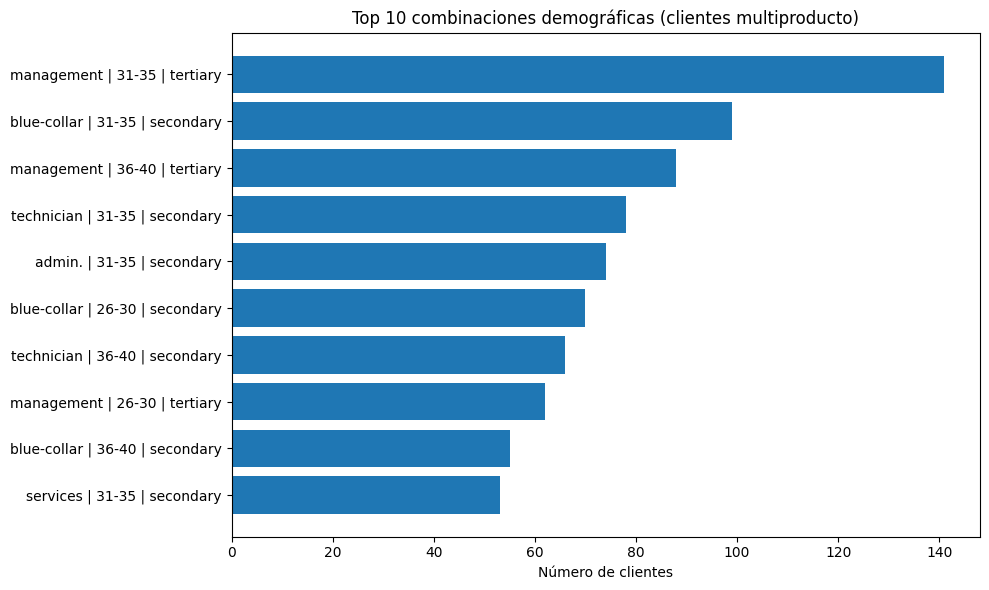

In [12]:

top_n = 10
top_profiles = grouped_by_level.head(top_n)

labels = (
    top_profiles["job"] + " | " +
    top_profiles["age_cat"].astype(str) + " | " +
    top_profiles["education"] #+ " | " +
    #top_profiles["num_products"].astype(str)
    
)

plt.figure(figsize=(10, 6))
plt.barh(labels, top_profiles["num_clients"])
plt.xlabel("Número de clientes")
plt.title("Top 10 combinaciones demográficas (clientes multiproducto)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Heatmap — Edad vs Educación (agregado)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_52384\622368768.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["age_cat", "education"])["num_clients"]


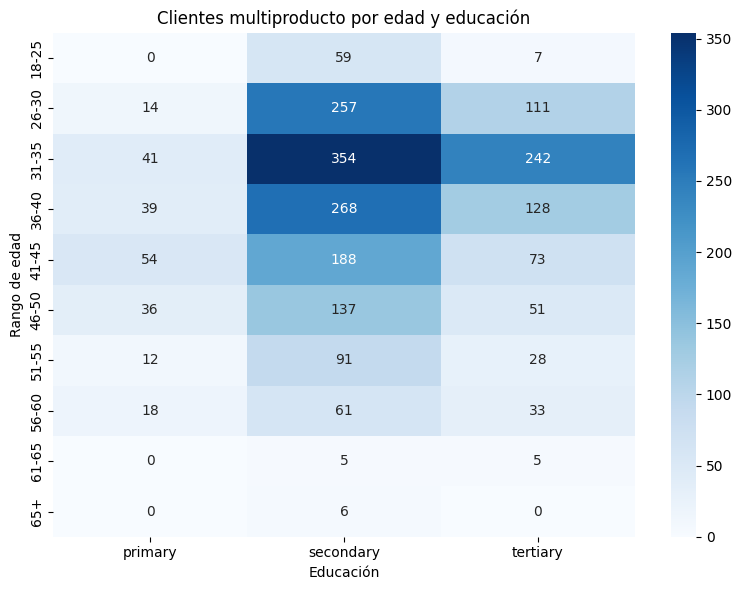

In [13]:
import seaborn as sns

heatmap_data = (
    grouped_by_level
    .groupby(["age_cat", "education"])["num_clients"]
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Blues")
plt.title("Clientes multiproducto por edad y educación")
plt.xlabel("Educación")
plt.ylabel("Rango de edad")
plt.tight_layout()
plt.show()


### Bar chart — Distribución por profesión

Responde si hay profesiones especialmente vinculadas.

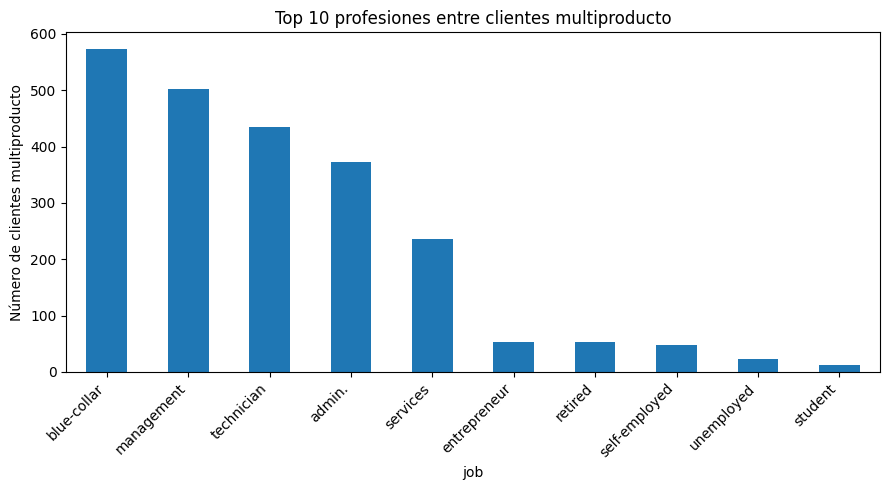

In [14]:
job_dist = (
    grouped_by_level
    .groupby("job")["num_clients"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
job_dist.plot(kind="bar")
plt.ylabel("Número de clientes multiproducto")
plt.title("Top 10 profesiones entre clientes multiproducto")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Stacked bar — Edad × Educación (composición)

👉 Cómo se compone cada rango de edad según educación.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_52384\1384229545.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["age_cat", "education"])["num_clients"]


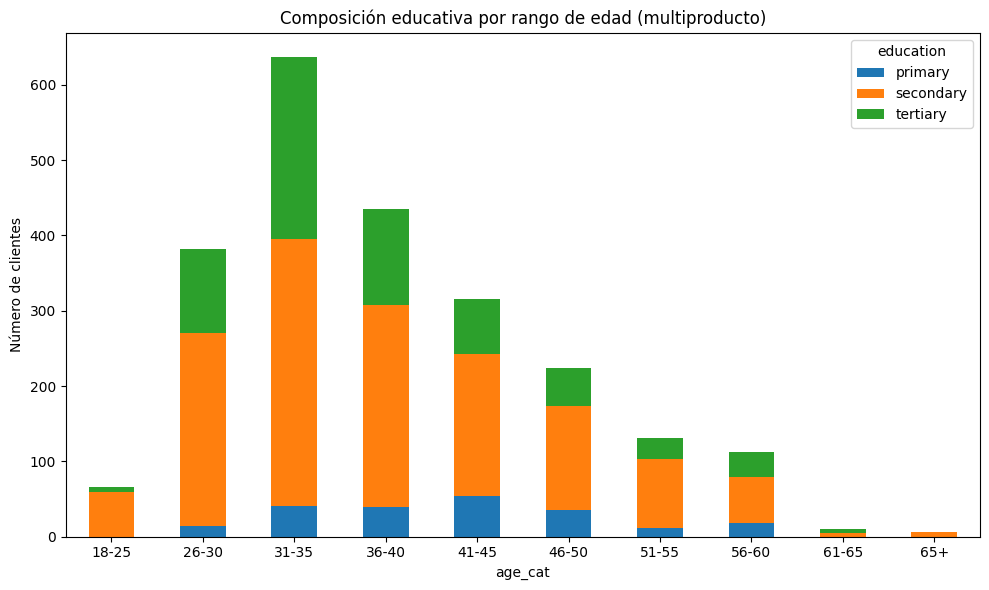

In [15]:
stack_data = (
    grouped_by_level
    .groupby(["age_cat", "education"])["num_clients"]
    .sum()
    .unstack(fill_value=0)
)

stack_data.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel("Número de clientes")
plt.title("Composición educativa por rango de edad (multiproducto)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Comparación 2 vs 3 productos

C:\Users\Usuario\AppData\Local\Temp\ipykernel_52384\3257326678.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["num_products", "age_cat"])["job"]


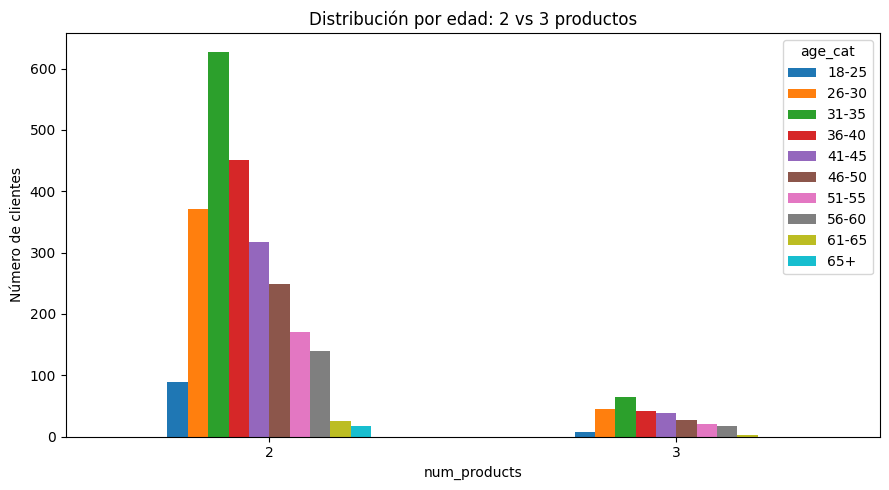

In [16]:
grouped_level = (
    df_multi
    .groupby(["num_products", "age_cat"])["job"]
    .count()
    .unstack(fill_value=0)
)

grouped_level.plot(kind="bar", figsize=(9, 5))
plt.ylabel("Número de clientes")
plt.title("Distribución por edad: 2 vs 3 productos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


__Perfil general del cliente multiproducto__

Los clientes con 2 o 3 productos muestran un patrón claro:

 - Edad dominante: __26–45 años, con especial peso en 26–35 y 36–45__

- Nivel educativo predominante: __Secondary, seguido de tertiary__

- Profesiones más frecuentes: __blue-collar, services, technician, admin.__

## -----------------------------
# Objetivo: Medir la sobrerepresantación de perfiles con Lift (Índice de Afinidad) + suport
## -----------------------------

- ¿Qué combinaciones de edad, educación y profesión están sobrerrepresentadas entre los clientes multiproducto respecto a la población total del banco?

Es decir:

- No solo cuáles son frecuentes

- Sino cuáles tienen mayor propensión al multiproducto

In [19]:
# baseline contra el que se calcula el Lift.Probabilidad media de que un cliente cualquiera sea multiproducto.
p_multi_global = df["is_multi"].mean()

# metrica por perfil demografico
profile_stats = (
    df
    .groupby(["age_cat", "education", "job"])
    .agg(
        total_clients=("is_multi", "count"),
        multi_clients=("is_multi", "sum")
    )
    .reset_index()
)

# Calcular Support, probabilidad condicional y Lift

########## Support
profile_stats["support"] = profile_stats["total_clients"] / len(df)

########## P(multiproducto | perfil)
profile_stats["p_multi_profile"] = (profile_stats["multi_clients"] / profile_stats["total_clients"])

########## Lift
profile_stats["lift"] = (profile_stats["p_multi_profile"] / p_multi_global)



C:\Users\Usuario\AppData\Local\Temp\ipykernel_52384\1661599227.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["age_cat", "education", "job"])


### Filtrar perfiles estadísticamente estables (MUY importante)

In [20]:
profile_clean = profile_stats[
    (profile_stats["total_clients"] >= 20) &
    (profile_stats["multi_clients"] >= 5) &
    ((profile_stats["lift"] >= 1.3) & (profile_stats["support"] >= 0.01))  # Filtrar perfiles con Lift significativamente alto o bajo
]
# ordenar por Lift
profile_clean = profile_clean.sort_values(by="support", ascending=False)
profile_clean.head(10)

,age_cat,education,job,total_clients,multi_clients,support,p_multi_profile,lift
121,31-35,secondary,blue-collar,273,110,0.024484,0.402930,1.650505
120,31-35,secondary,admin.,235,82,0.021076,0.348936,1.429331
73,26-30,secondary,blue-collar,211,83,0.018924,0.393365,1.611322
72,26-30,secondary,admin.,179,62,0.016054,0.346369,1.418814
176,36-40,secondary,services,165,55,0.014798,0.333333,1.365418
217,41-45,secondary,blue-collar,147,51,0.013184,0.346939,1.421149
109,31-35,primary,blue-collar,114,41,0.010224,0.359649,1.473214
265,46-50,secondary,blue-collar,113,43,0.010135,0.380531,1.558751


In [21]:
# guarddar el DataFrame resultante en un archivo excel
profile_clean.to_excel("C:\\LLUIS\\Dropbox\\IT ACADEMY\\Simulacio Empresarial Docs\\Sprint03\\profile_lift_analysis.xlsx", index=False)

## grafico
__Bar chart — Índice de sobre-representación (LIFT)__

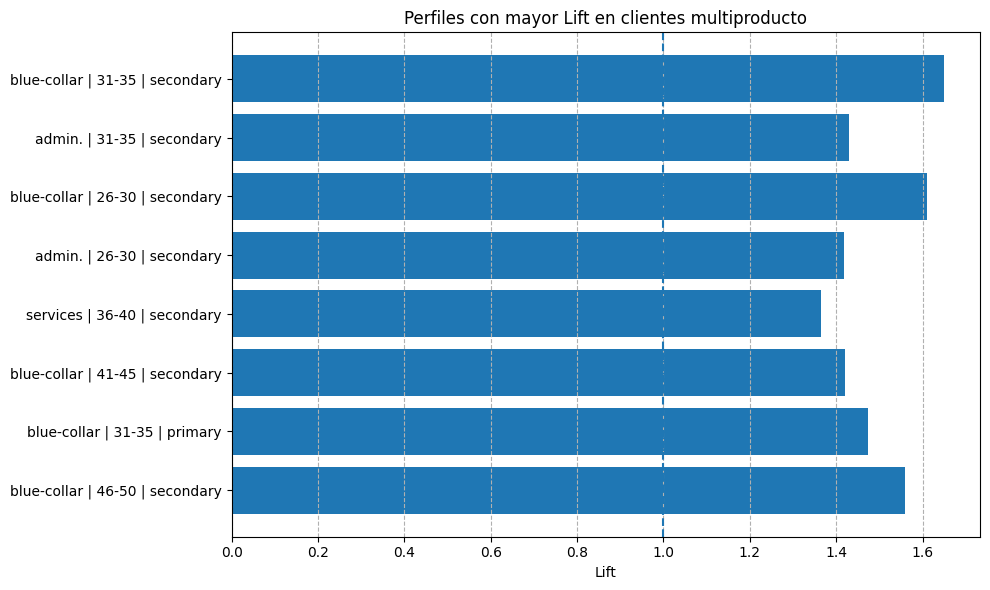

In [22]:
import matplotlib.pyplot as plt

top_over = profile_clean.head(10)

labels = (
    top_over["job"] + " | " +
    top_over["age_cat"].astype(str) + " | " +
    top_over["education"]
    
)

plt.figure(figsize=(10, 6))
plt.barh(labels, top_over["lift"])
plt.axvline(1, linestyle="--")
plt.xlabel("Lift")
plt.title("Perfiles con mayor Lift en clientes multiproducto")
plt.grid(axis='x', linestyle='--')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## grafico representando lift y support

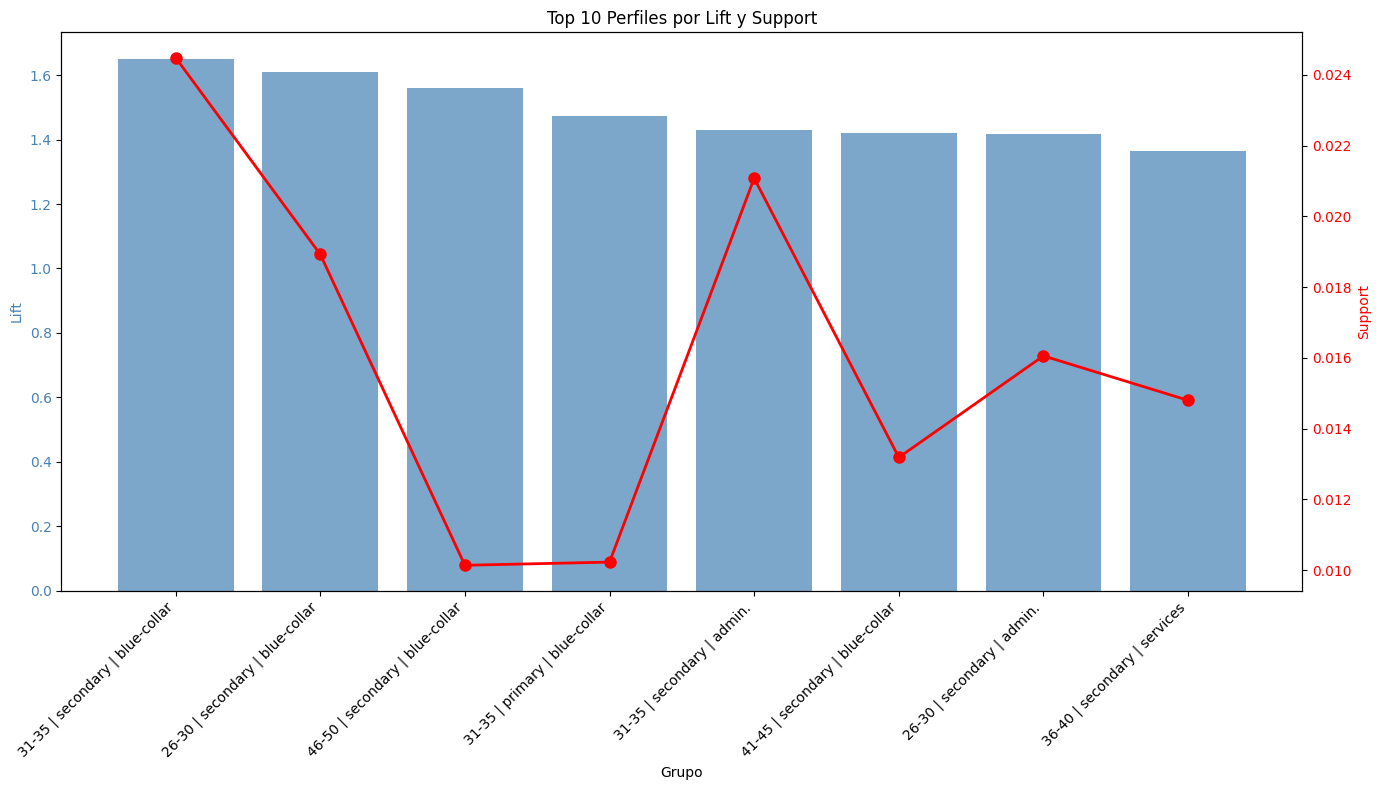

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear DataFrame
df_lift = profile_clean.copy()


# Ordenar y seleccionar top 10
top10 = df_lift.sort_values(by='lift', ascending=False).head(10).copy()
# Crear etiqueta combinada
top10['etiqueta'] = top10.apply(
    lambda row: f"{str(row['age_cat'])} | {str(row['education'])} | {str(row['job'])}", 
    axis=1
)

# Crear gráfico
fig, ax1 = plt.subplots(figsize=(14, 8))

# Barras para lift
bars = ax1.bar(range(len(top10)), top10['lift'], alpha=0.7, color='steelblue', label='Lift')
ax1.set_xlabel('Grupo')
ax1.set_ylabel('Lift', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(range(len(top10)))
ax1.set_xticklabels(top10['etiqueta'], rotation=45, ha='right')

# Línea para support
ax2 = ax1.twinx()
ax2.plot(range(len(top10)), top10['support'], 'r-o', linewidth=2, markersize=8, label='Support')
ax2.set_ylabel('Support', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Título y diseño
plt.title('Top 10 Perfiles por Lift y Support')
fig.tight_layout()
plt.show()

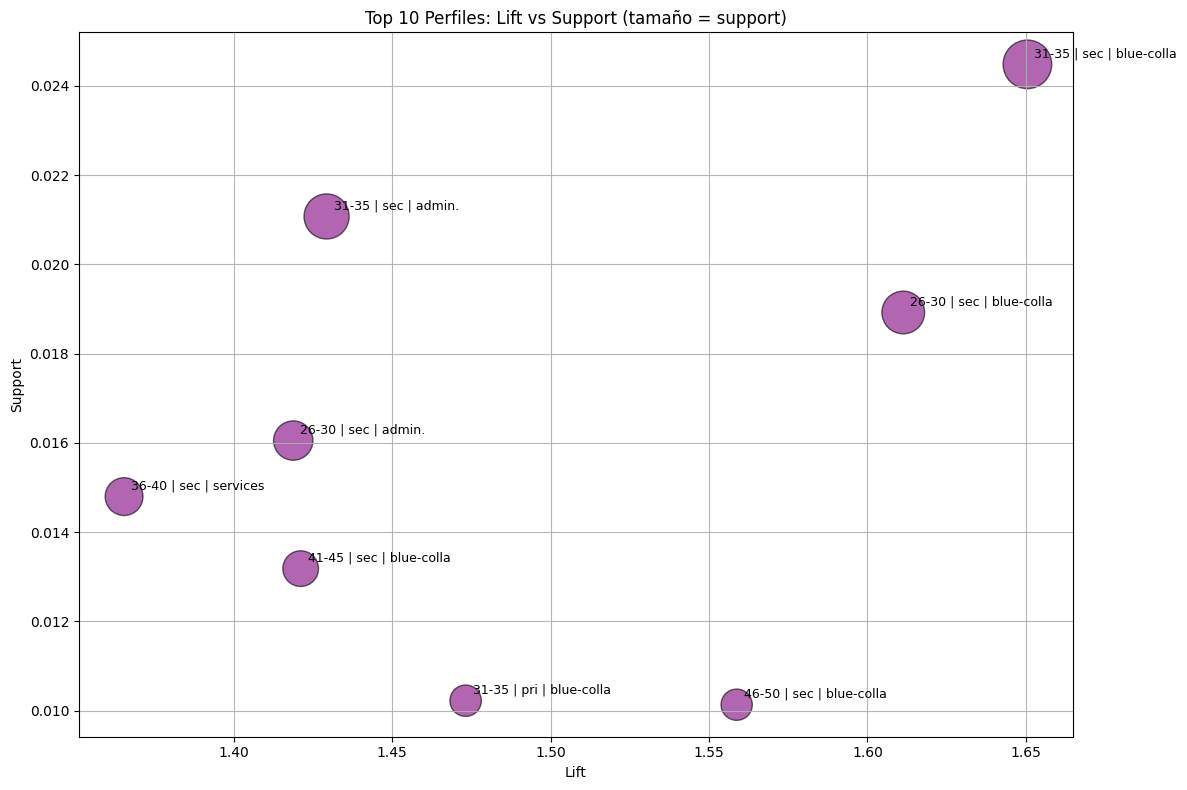

In [24]:


# Crear DataFrame
df_lift = profile_clean.copy()

# Ordenar y seleccionar top 10
top10 = df_lift.sort_values(by='lift', ascending=False).head(10).copy()

# Crear etiquetas
top10['etiqueta'] = top10.apply(
    lambda x: f"{x['age_cat']} | {x['education'][:3]} | {x['job'][:10]}", 
    axis=1
)

# Gráfico de dispersión con tamaño de burbuja
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    x=top10['lift'], 
    y=top10['support'],
    s=top10['support'] * 50000,  # Tamaño basado en support
    alpha=0.6,
    c='purple',
    edgecolors='black'
)

# Añadir etiquetas
for i, row in top10.iterrows():
    plt.annotate(
        row['etiqueta'], 
        (row['lift'], row['support']),
        xytext=(5, 5), 
        textcoords='offset points',
        fontsize=9
    )

plt.xlabel('Lift')
plt.ylabel('Support')
plt.title('Top 10 Perfiles: Lift vs Support (tamaño = support)')
plt.grid(True, alpha=0.9)
plt.tight_layout()
plt.show()

## Interpretación correcta 
### _Support_

__¿Qué porcentaje del total de clientes pertenece a este perfil?__

- Bajo support + Lift alto → nicho

- Support medio/alto + Lift alto → perfil estratégico

### _Lift_

__¿Cuántas veces más probable es que este perfil sea multiproducto respecto al promedio?__

- Lift = 1 → comportamiento medio

- Lift > 1.3 → afinidad relevante

- Lift > 1.7 → afinidad fuerte

- Lift > 2 → perfil prioritario

__Explicación:__

Los perfiles demográficos se evaluaron mediante métricas de soporte y Lift. El soporte permitió descartar combinaciones con baja representatividad, mientras que el Lift cuantificó la afinidad relativa al multiproducto. Los resultados muestran que determinados perfiles presentan una probabilidad de ser multiproducto entre 1.5 y 2 veces superior a la media del banco, lo que confirma la existencia de segmentos demográficos con alta propensión a la contratación de múltiples productos financieros.

### Perfiles SOBRERREPRESENTADOS (comparación contra población total)

__Aquí está el punto clave: no los más numerosos, sino los más propensos con amyor soporte.__

Perfil (Edad-Educación-Ocupación)	Support (% multiproducto)	Lift (Afinidad)
- 31–35, Secondary, Blue-collar	2.45%	1.65
- 31–35, Secondary, Admin.	2.11%	1.43
- 26–30, Secondary, Blue-collar	1.89%	1.61
- 26–30, Secondary, Admin.	1.61%	1.42
- 36–40, Secondary, Services	1.48%	1.37
- 41–45, Secondary, Blue-collar	1.32%	1.42
- 31–35, Primary, Blue-collar	1.02%	1.47
- 46–50, Secondary, Blue-collar	1.01%	1.56

### __Conclusiones__:
Los clientes multiproducto del banco están sobrerrepresentados entre individuos de 26 a 45 años, con nivel educativo secondary y ocupaciones operativas como blue-collar, services y technician. En particular, los jóvenes de 18–25 años con formación secundaria y empleos técnicos presentan más del doble de probabilidad de contratar múltiples productos financieros en comparación con la población total del banco.

## Las conclusiones se sustentan en el Índice de Afinidad (Lift), que muestra una sobrerrepresentación clara de determinados perfiles demográficos entre los clientes multiproducto. Esta evidencia se puede reforzar mediante medidas de soporte y validación estadística (chi-cuadrado) o modelos explicativos como regresión logística.

# -----------------------------
# Objetivo: del Test Chi-cuadrado
# -----------------------------
__Contrastar si existe asociación estadísticamente significativa entre:__

- Ser cliente multiproducto (≥ 2 productos)

- y una variable demográfica (age_range, education, job)

Formalmente:

¿La propensión al multiproducto es independiente del perfil demográfico?

## Test Chi-cuadrado: concepto

- Variables categóricas

- Tabla de contingencia

__Contrasta:__

- H₀: no hay asociación (independencia)

- H₁: sí hay asociación

### Chi-cuadrado: con age_cat

In [25]:
#import pandas as pd
from scipy.stats import chi2_contingency

contingency_age = pd.crosstab(
    df["age_cat"],
    df["is_multi"]
)
print(contingency_age.head())
# aplicamos la prueba chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(contingency_age)

#resultados
print(f"Chi²: {chi2:.3f}")
print(f"p-value: {p_value:.5f}")
print(f"Grados de libertad: {dof}")


is_multi     0    1
age_cat            
18-25      352   96
26-30     1138  416
31-35     1667  692
36-40     1338  493
41-45      977  355
Chi²: 181.850
p-value: 0.00000
Grados de libertad: 9


### Chi-cuadrado: con education

In [26]:
contingency_edu = pd.crosstab(
    df["education"],
    df["is_multi"]
)
print(contingency_edu.head())
# aplicamos la prueba chi-cuadrado
chi2, p_value, dof, _ = chi2_contingency(contingency_edu)
print(f"Chi²: {chi2:.3f}")
print(f"p-value: {p_value:.5f}")

is_multi         0     1
education               
not_provided   423    73
primary       1170   328
secondary     3937  1535
tertiary      2898   786
Chi²: 88.584
p-value: 0.00000


### Chi-cuadrado: con job

In [27]:
contingency_job = pd.crosstab(
    df["job"],
    df["is_multi"]
)
print(contingency_job.head())
# aplicamos la prueba chi-cuadrado
chi2, p_value, dof, _ = chi2_contingency(contingency_job)
print(f"Chi²: {chi2:.3f}")
print(f"p-value: {p_value:.5f}")

is_multi         0    1
job                    
admin.         923  410
blue-collar   1317  626
entrepreneur   233   94
housemaid      238   36
management    2012  550
Chi²: 337.992
p-value: 0.00000


### Verificación de supuestos (MUY importante)

El Chi-cuadrado exige:

Frecuencias esperadas ≥ 5 en la mayoría de celdas

In [28]:
expected_df = pd.DataFrame(
    expected,
    index=contingency_age.index,
    columns=contingency_age.columns
)

print(f"Valores menores que 5: {(expected_df < 5).sum().sum()}")


Valores menores que 5: 0


__Si el resultado es 0, significa:__

✔️ Todas las celdas cumplen el supuesto del Chi-cuadrado

✔️ No hay categorías raras con poco volumen

✔️ El test es totalmente válido

### Interpretación correcta

👉 Se rechaza con mucha fuerza la hipótesis nula de independencia para:

- age_cat

- education

- job

__En lenguaje claro:__

Existe una asociación estadísticamente muy significativa entre cada una de estas variables y el hecho de ser cliente multiproducto.

Existe una __asociación estadísticamente significativa__ entre la edad, la educación y la ocupación con la condición de cliente multiproducto (p < 0.001). No obstante, __el tamaño del efecto es moderado__, por lo que la relevancia práctica se evalúa mediante métricas de afinidad como el Lift y el soporte.

# -----------------------------
# Objetivo: Medir la fuerza de la asociación (V de Cramér).
# -----------------------------

__Entre:__
- Ser cliente multiproducto (sí / no)

- y cada variable demográfica (age_range, education, job)

__usando V de Cramér__, que es la medida adecuada tras un Chi-cuadrado significativo.

### Define una función reutilizable clara y correcta

In [29]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

def cramers_v(contingency_table):
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.values.sum()
    k = min(contingency_table.shape)
    return np.sqrt(chi2 / (n * (k - 1)))


### Cálculo para variable cat_age

In [30]:
ct_age = pd.crosstab(df["age_cat"], df["is_multi"])
v_age = cramers_v(ct_age)
v_age


np.float64(0.12770832004854388)

### Cálculo para variable education

In [31]:
ct_edu = pd.crosstab(df["education"], df["is_multi"])
v_edu = cramers_v(ct_edu)
v_edu


np.float64(0.08913359242375272)

### Cálculo para variable job

In [32]:
ct_job = pd.crosstab(df["job"], df["is_multi"])
v_job = cramers_v(ct_job)
v_job


np.float64(0.17410684488175096)

### Resultados

- job: V = 0.17410684488175096

- age_cat: V = 0.12770832004854388

- education: V = 0.08913359242375272


Nos dice que el que tiene mas fuerza y portanto mas relevante es job. __Orden con mas fuerza es : job > edad > educación__

El tamaño del efecto, medido mediante V de Cramér, muestra asociaciones débiles entre las variables demográficas y la condición de cliente multiproducto. La ocupación presenta la mayor fuerza explicativa (V = 0.17), seguida de la edad (V = 0.13), mientras que el nivel educativo muestra una influencia limitada (V = 0.09). Estos resultados indican que __el multiproducto no depende de un único factor demográfico, sino de combinaciones específicas de perfil__, lo que justifica el uso de métricas de afinidad como el Lift para la identificación de segmentos de alto valor.

# -----------------------------
# Relación final con tus resultados previos
# -----------------------------
Ahora tu análisis queda cerrado así:

✔️ Chi-cuadrado → asociación real

✔️ V de Cramér → fuerza débil–moderada

✔️ Lift → afinidad concreta y explotable

✔️ Support → estabilidad y volumen

👉 No hay contradicciones: se complementan perfectamente.

# -----------------------------
# EXTRA: CLIENTES NO MULTIPRODUCTO vs  MULTIPRODUCTO
### para propuestas de negocio
# -----------------------------

In [33]:
grouped_by_sociodemograficas = (
    df
    .groupby(["num_products", "age_cat", "education", "job","is_multi"])
    .size()
    .reset_index(name="num_clients")
)

#convierto a porcentaje
grouped_by_sociodemograficas['pct_clients'] = grouped_by_sociodemograficas['num_clients'] / grouped_by_sociodemograficas['num_clients'].sum() * 100

grouped_by_sociodemograficas = (
    grouped_by_sociodemograficas
    .sort_values(by="num_clients", ascending=False)
)

# Revisa combinaciones con num_clients = 1 → ruido
grouped_by_sociodemograficas = grouped_by_sociodemograficas[grouped_by_sociodemograficas["num_clients"] >= 15]

# filtro != 'not_provided' education level
grouped_by_sociodemograficas = grouped_by_sociodemograficas[grouped_by_sociodemograficas['education'] != 'not_provided']

grouped_by_sociodemograficas.head(10)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_52384\3078747063.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["num_products", "age_cat", "education", "job","is_multi"])


,num_products,age_cat,education,job,is_multi,num_clients,pct_clients
1232,1,31-35,tertiary,management,0,328,2.941704
1328,1,36-40,tertiary,management,0,223,2.000000
1136,1,26-30,tertiary,management,0,192,1.721973
1424,1,41-45,tertiary,management,0,148,1.327354
2193,2,31-35,tertiary,management,1,141,1.264574
1202,1,31-35,secondary,blue-collar,0,136,1.219731
1220,1,31-35,secondary,technician,0,136,1.219731
272,0,31-35,tertiary,management,0,130,1.165919
1520,1,46-50,tertiary,management,0,129,1.156951
1200,1,31-35,secondary,admin.,0,123,1.103139


### grafico de % de multi_producto>=2 contra no_muliproducto<2

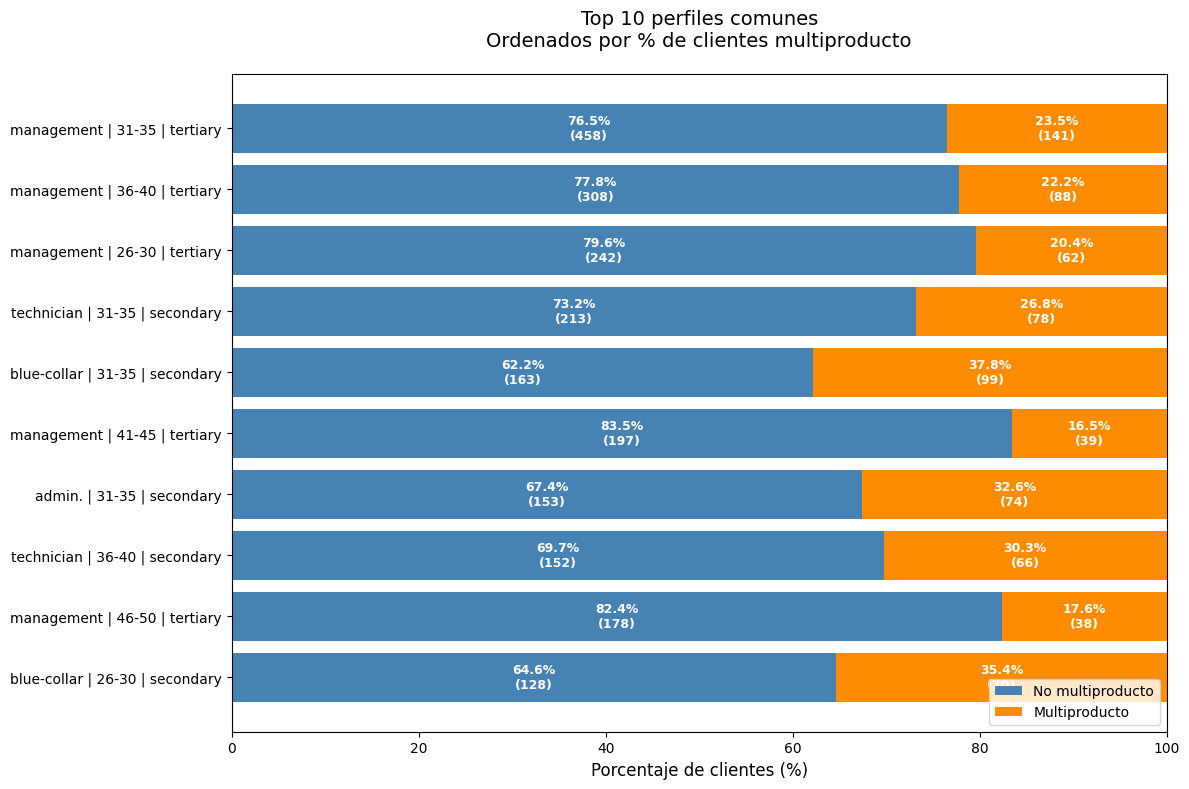

Top 10 perfiles ordenados por % multiproducto:


,Trabajo,Edad,Educación,No Multi,Multi,Total,% No Multi,% Multi
32,management,31-35,tertiary,458,141,599,76.5,23.5
4,management,36-40,tertiary,308,88,396,77.8,22.2
17,management,26-30,tertiary,242,62,304,79.6,20.4
1,technician,31-35,secondary,213,78,291,73.2,26.8
29,blue-collar,31-35,secondary,163,99,262,62.2,37.8
33,management,41-45,tertiary,197,39,236,83.5,16.5
3,admin.,31-35,secondary,153,74,227,67.4,32.6
13,technician,36-40,secondary,152,66,218,69.7,30.3
26,management,46-50,tertiary,178,38,216,82.4,17.6
2,blue-collar,26-30,secondary,128,70,198,64.6,35.4


In [34]:
 
# top_n = 10

# Filtrar los datos
No_df_multi = grouped_by_sociodemograficas[grouped_by_sociodemograficas["num_products"] < 2].copy()
df_multi = grouped_by_sociodemograficas[grouped_by_sociodemograficas["num_products"] >= 2].copy()

# Crear claves de perfil
No_df_multi["profile_key"] = No_df_multi["job"] + "|" + No_df_multi["age_cat"].astype(str) + "|" + No_df_multi["education"]
df_multi["profile_key"] = df_multi["job"] + "|" + df_multi["age_cat"].astype(str) + "|" + df_multi["education"]

# Encontrar perfiles comunes
common_profiles = set(No_df_multi["profile_key"]).intersection(set(df_multi["profile_key"]))

# Agregar datos
data = []
for profile in common_profiles:
    no_multi_val = No_df_multi[No_df_multi["profile_key"] == profile]["num_clients"].sum()
    multi_val = df_multi[df_multi["profile_key"] == profile]["num_clients"].sum()
    total = no_multi_val + multi_val
    
    data.append({
        "profile": profile,
        "no_multi": no_multi_val,
        "multi": multi_val,
        "total": total,
        "pct_multi": (multi_val / total * 100) if total > 0 else 0
    })

combined_df = pd.DataFrame(data)
combined_df[["job", "age_cat", "education"]] = combined_df["profile"].str.split("|", expand=True)

# ORDENAR POR % MULTIPRODUCTO (de mayor a menor)
combined_df = combined_df.sort_values("total", ascending=False).head(top_n)

# Gráfico de barras apiladas horizontales con porcentajes
fig, ax = plt.subplots(figsize=(12, 8))

# Crear barras apiladas
bars_no_multi = ax.barh(range(len(combined_df)), combined_df["no_multi"] / combined_df["total"] * 100,
                       color='steelblue', label='No multiproducto')
bars_multi = ax.barh(range(len(combined_df)), combined_df["multi"] / combined_df["total"] * 100,
                     left=combined_df["no_multi"] / combined_df["total"] * 100,
                     color='darkorange', label='Multiproducto')

# Configurar eje X como porcentaje
ax.set_xlim(0, 100)
ax.set_xlabel("Porcentaje de clientes (%)", fontsize=12)

# Configurar etiquetas en eje Y
labels = combined_df["job"] + " | " + combined_df["age_cat"] + " | " + combined_df["education"]
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()  # Para mostrar el perfil con mayor % multiproducto arriba

# Título
ax.set_title(f"Top {top_n} perfiles comunes\nOrdenados por % de clientes multiproducto", fontsize=14, pad=20)

# Leyenda
ax.legend(loc='lower right')

# Agregar etiquetas con porcentajes y valores absolutos
for i, (idx, row) in enumerate(combined_df.iterrows()):
    no_multi_pct = row["no_multi"] / row["total"] * 100
    multi_pct = row["multi"] / row["total"] * 100
    
    # Etiqueta para No multiproducto
    if no_multi_pct > 0:
        label_text = f"{no_multi_pct:.1f}%\n({int(row['no_multi']):,})"
        ax.text(no_multi_pct/2, i, label_text,
                ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    # Etiqueta para Multiproducto
    if multi_pct > 0:
        label_text = f"{multi_pct:.1f}%\n({int(row['multi']):,})"
        ax.text(no_multi_pct + multi_pct/2, i, label_text,
                ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Mostrar tabla resumen
print(f"Top {top_n} perfiles ordenados por % multiproducto:")
result_table = combined_df[["job", "age_cat", "education", "no_multi", "multi", "total", "pct_multi"]].copy()
result_table["pct_multi"] = result_table["pct_multi"].round(1)
result_table["pct_no_multi"] = 100 - result_table["pct_multi"]
result_table = result_table[["job", "age_cat", "education", "no_multi", "multi", "total", "pct_no_multi", "pct_multi"]]
result_table.columns = ["Trabajo", "Edad", "Educación", "No Multi", "Multi", "Total", "% No Multi", "% Multi"]
result_table